# 05 — Sensitivity to kNN parameter k

**Purpose:** Test sensitivity to k (number of neighbors in the kNN graph). Vary k ∈ {10, 20, 30, 50}, compute spatial metrics, plot stabilization curves.

## Imports and path setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.sparse.csgraph import connected_components as sparse_connected_components

warnings.filterwarnings("ignore", message=".*not fully connected.*", category=UserWarning)

from analysis.experiment_runner import _get_run_dirs
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import load_meta, run_multiplicity, run_spatial

RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Loop over k and store results

In [2]:
K = 25
K_NN_LIST = [10, 20, 30, 50]

SUPPORTED_DATASETS = ("compas", "german", "breast_cancer")
dataset_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and p.name in SUPPORTED_DATASETS and _get_run_dirs(p)]

def run_one_knn(run_dir, X_test, k_nn):
    n_cand = len(load_meta(run_dir))
    K_actual = min(K, n_cand)
    mult = run_multiplicity(run_dir, K=K_actual)
    spatial = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)

    W = spatial["W"]
    W_sparse = W.to_sparse() if hasattr(W, "to_sparse") else W.sparse
    W_sym = W_sparse + W_sparse.T
    W_sym = (W_sym > 0).astype(int)
    n_comp, comp_labels = sparse_connected_components(W_sym, directed=False)
    comp_sizes = np.bincount(comp_labels)
    largest_frac = int(comp_sizes.max()) / W_sym.shape[0]

    return {
        "mean_variance": mult["mean_variance"],
        "mean_conflict": mult["mean_conflict"],
        "moran_i": spatial["moran_i"],
        "n_hh": int(np.sum(spatial["HH_mask"])),
        "conflict_moran_i": spatial.get("conflict_moran_i", np.nan),
        "conflict_n_hh": spatial.get("conflict_n_hh", 0),
        "n_components": n_comp,
        "largest_component_frac": largest_frac,
        "HH_mask": spatial["HH_mask"],
        "X_test": X_test,
    }

results_knn = []
hh_data_by_knn = {}  # (dataset, seed, k_nn) -> {"HH_mask": ..., "X_test": ...}
for dataset_dir in dataset_dirs:
    dataset_name = dataset_dir.name
    run_dirs = _get_run_dirs(dataset_dir)
    for k_nn_val in K_NN_LIST:
        for run_dir in run_dirs:
            X_test = get_transformed_test_features(run_dir, dataset_name)
            res = run_one_knn(run_dir, X_test, k_nn_val)
            hh_mask = res.pop("HH_mask")
            x_test = res.pop("X_test")
            key = (dataset_name, run_dir.name, k_nn_val)
            hh_data_by_knn[key] = {"HH_mask": hh_mask, "X_test": x_test}
            results_knn.append({"dataset": dataset_name, "seed": run_dir.name, "k_nn": k_nn_val, **res})

df_knn = pd.DataFrame(results_knn)
print(df_knn.groupby(["dataset", "k_nn"]).agg({
    "mean_variance": ["mean", "std"], "mean_conflict": ["mean", "std"],
    "moran_i": ["mean", "std"], "n_hh": "mean",
    "conflict_moran_i": ["mean", "std"], "conflict_n_hh": "mean",
    "n_components": ["mean", "min", "max"], "largest_component_frac": ["mean", "min"],
}).round(4))

                   mean_variance         mean_conflict         moran_i  \
                            mean     std          mean     std    mean   
dataset       k_nn                                                       
breast_cancer 10          0.0032  0.0026        0.0115  0.0084  0.0758   
              20          0.0032  0.0026        0.0115  0.0084  0.0538   
              30          0.0032  0.0026        0.0115  0.0084  0.0315   
              50          0.0032  0.0026        0.0115  0.0084  0.0048   
compas        10          0.0013  0.0003        0.0354  0.0070  0.2943   
              20          0.0013  0.0003        0.0354  0.0070  0.2304   
              30          0.0013  0.0003        0.0354  0.0070  0.1993   
              50          0.0013  0.0003        0.0354  0.0070  0.1627   
german        10          0.0050  0.0021        0.0593  0.0219  0.1576   
              20          0.0050  0.0021        0.0593  0.0219  0.1280   
              30          0.0050  0.00

## Stabilization curves

Mean ± std bands over seeds for variance-based and conflict-based metrics, plus mean_variance to confirm it is constant w.r.t. k.

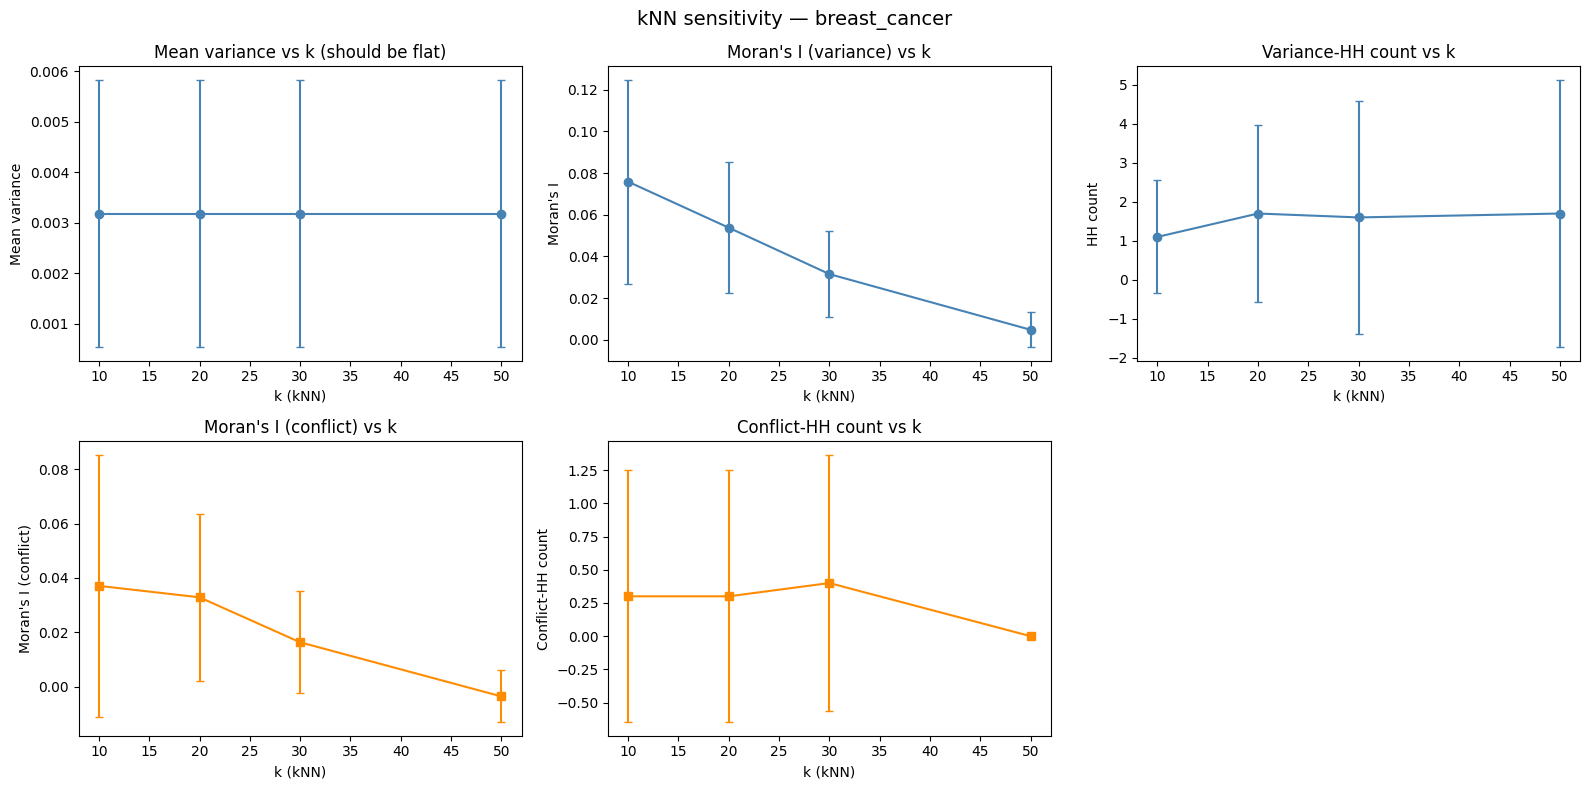

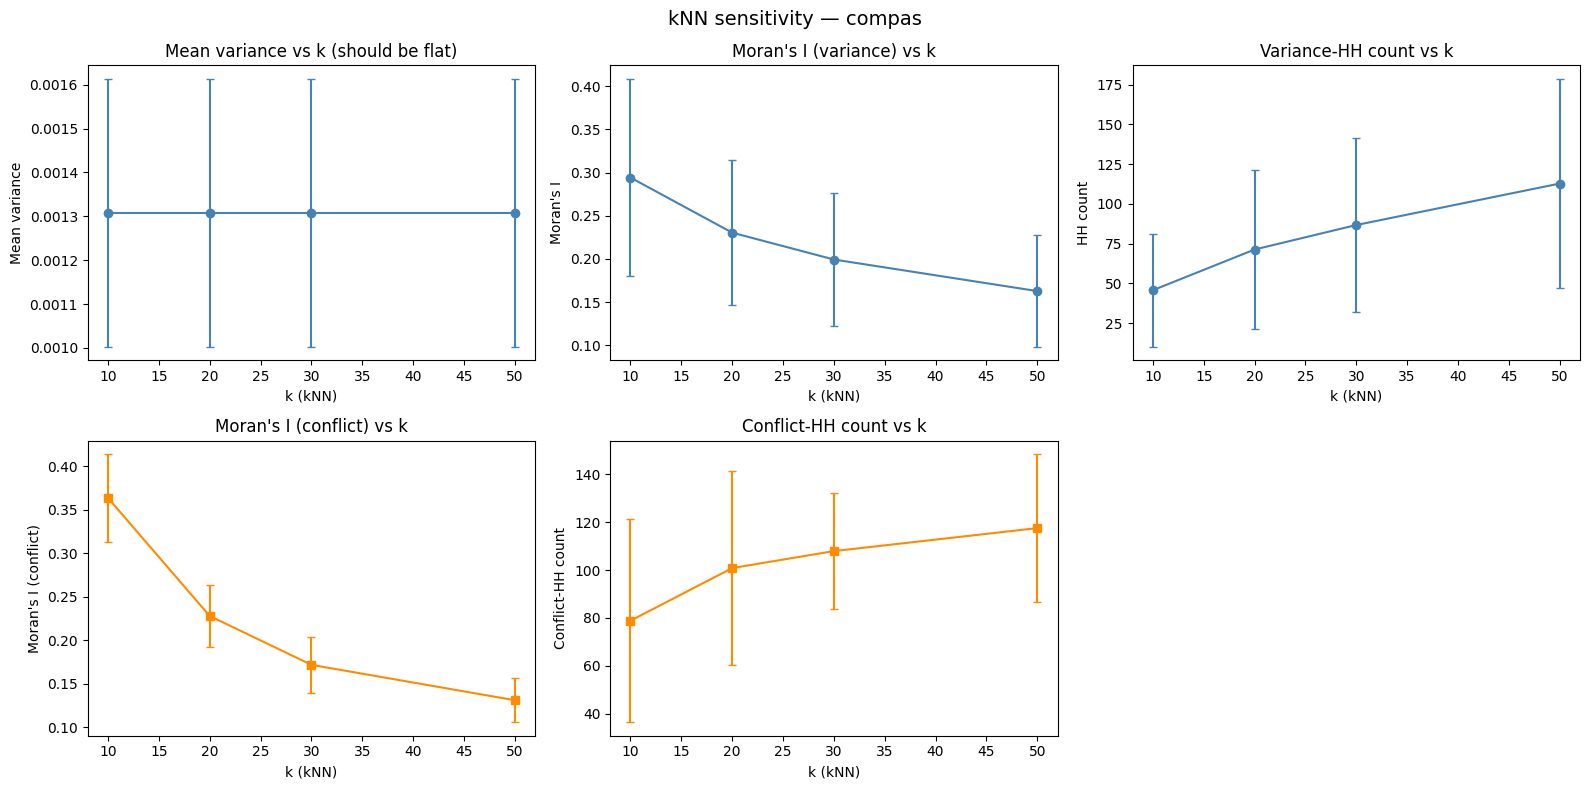

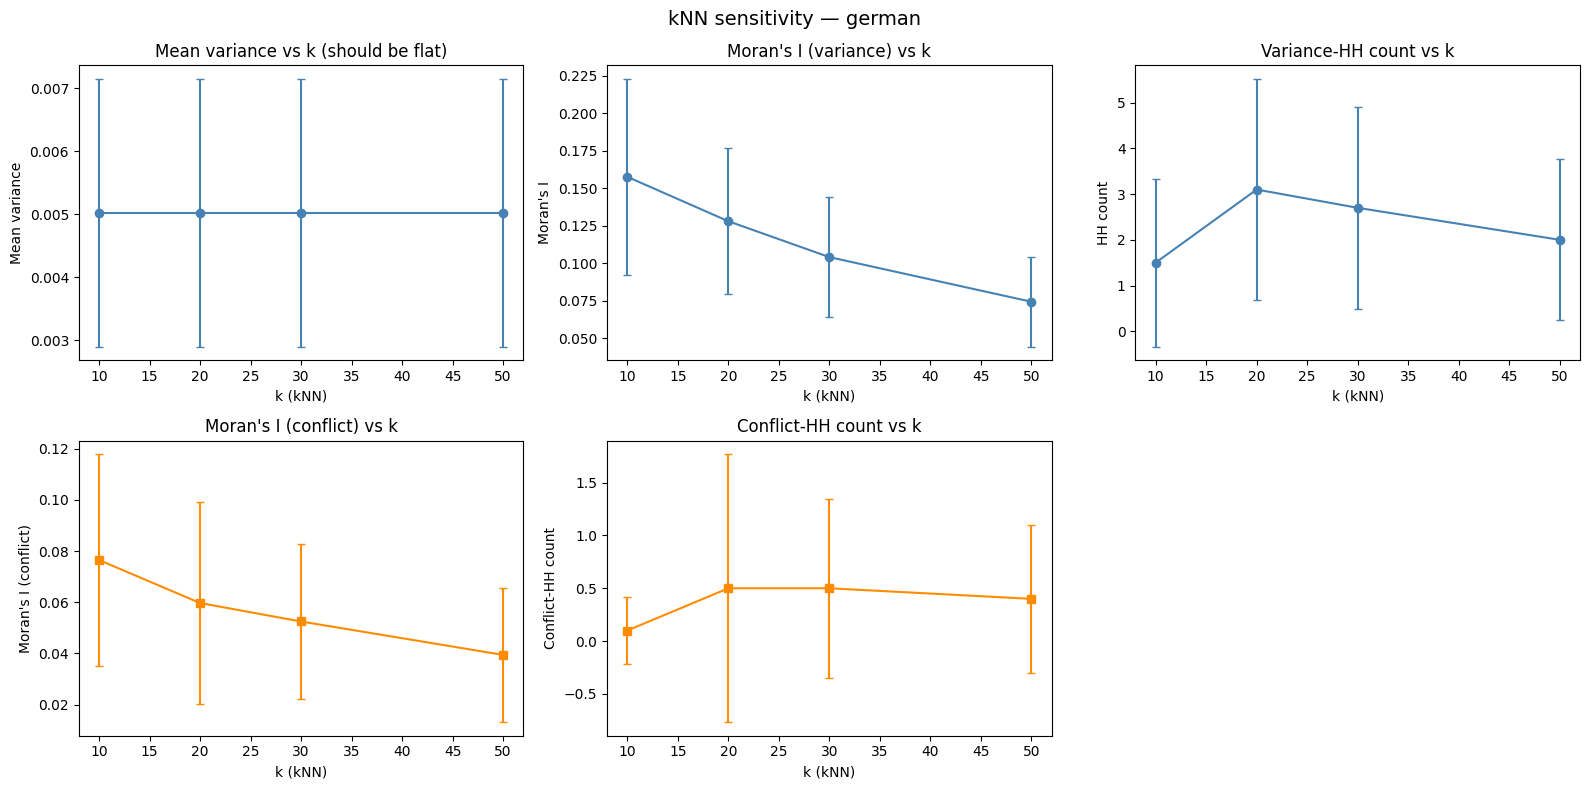

In [3]:
agg_knn = df_knn.groupby(["dataset", "k_nn"]).agg(
    mean_variance_mean=("mean_variance", "mean"), mean_variance_std=("mean_variance", "std"),
    moran_mean=("moran_i", "mean"), moran_std=("moran_i", "std"),
    n_hh_mean=("n_hh", "mean"), n_hh_std=("n_hh", "std"),
    conflict_moran_mean=("conflict_moran_i", "mean"), conflict_moran_std=("conflict_moran_i", "std"),
    conflict_n_hh_mean=("conflict_n_hh", "mean"), conflict_n_hh_std=("conflict_n_hh", "std"),
).reset_index()

for ds_name, ds_agg in agg_knn.groupby("dataset"):
    d = ds_agg
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    axes[0, 0].errorbar(d["k_nn"], d["mean_variance_mean"], yerr=d["mean_variance_std"], marker="o", capsize=3, color="steelblue")
    axes[0, 0].set_xlabel("k (kNN)"); axes[0, 0].set_ylabel("Mean variance"); axes[0, 0].set_title("Mean variance vs k (should be flat)")

    axes[0, 1].errorbar(d["k_nn"], d["moran_mean"], yerr=d["moran_std"], marker="o", capsize=3, color="steelblue")
    axes[0, 1].set_xlabel("k (kNN)"); axes[0, 1].set_ylabel("Moran's I"); axes[0, 1].set_title("Moran's I (variance) vs k")

    axes[0, 2].errorbar(d["k_nn"], d["n_hh_mean"], yerr=d["n_hh_std"], marker="o", capsize=3, color="steelblue")
    axes[0, 2].set_xlabel("k (kNN)"); axes[0, 2].set_ylabel("HH count"); axes[0, 2].set_title("Variance-HH count vs k")

    axes[1, 0].errorbar(d["k_nn"], d["conflict_moran_mean"], yerr=d["conflict_moran_std"], marker="s", capsize=3, color="darkorange")
    axes[1, 0].set_xlabel("k (kNN)"); axes[1, 0].set_ylabel("Moran's I (conflict)"); axes[1, 0].set_title("Moran's I (conflict) vs k")

    axes[1, 1].errorbar(d["k_nn"], d["conflict_n_hh_mean"], yerr=d["conflict_n_hh_std"], marker="s", capsize=3, color="darkorange")
    axes[1, 1].set_xlabel("k (kNN)"); axes[1, 1].set_ylabel("Conflict-HH count"); axes[1, 1].set_title("Conflict-HH count vs k")

    axes[1, 2].set_visible(False)

    fig.suptitle(f"kNN sensitivity — {ds_name}", fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_kNN_curves_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

## Graph connectivity diagnostic

Number of connected components and largest component fraction as a function of k_nn. Small k can lead to disconnected graphs.

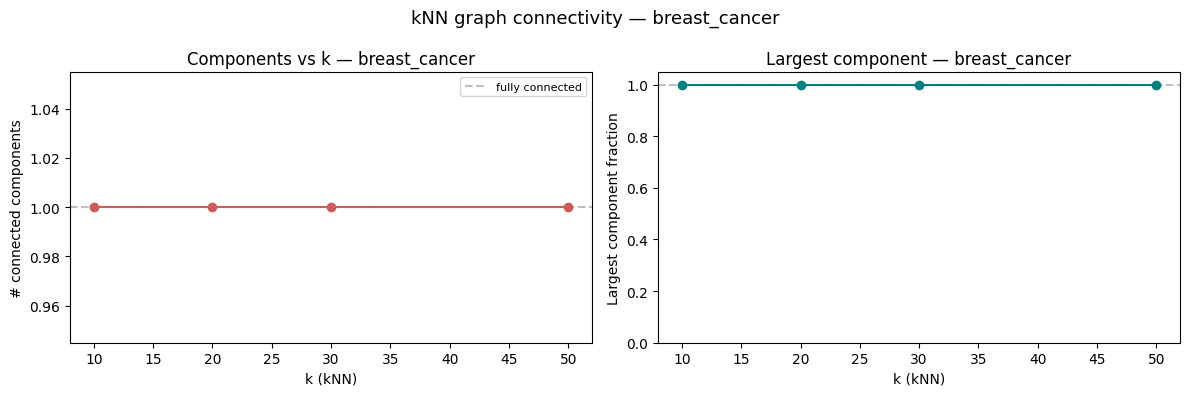

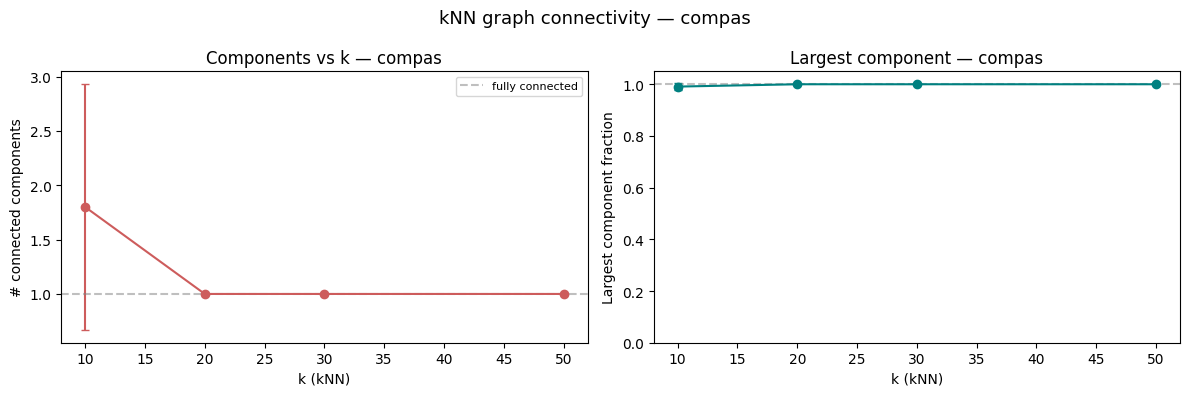

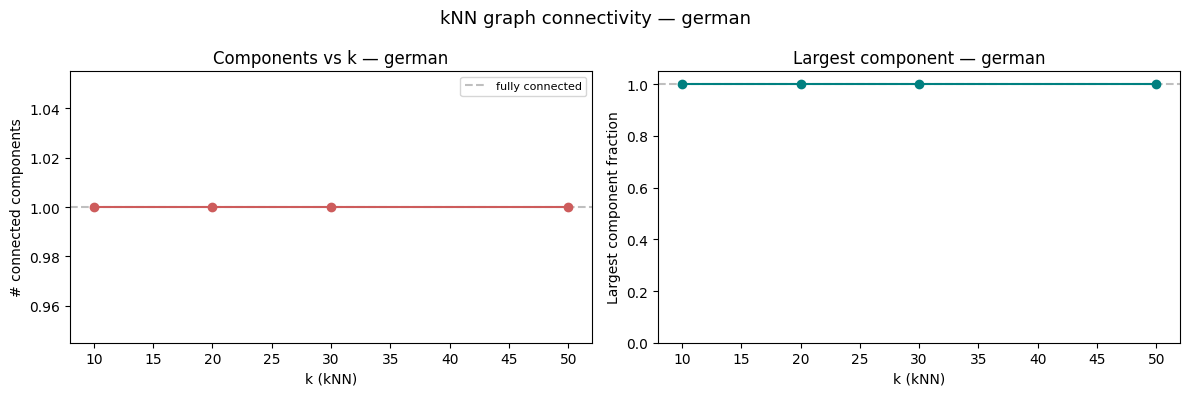

In [4]:
conn_agg = df_knn.groupby(["dataset", "k_nn"]).agg(
    comp_mean=("n_components", "mean"), comp_std=("n_components", "std"),
    comp_max=("n_components", "max"),
    frac_mean=("largest_component_frac", "mean"), frac_std=("largest_component_frac", "std"),
    frac_min=("largest_component_frac", "min"),
).reset_index()

for ds_name, ds_data in conn_agg.groupby("dataset"):
    d = ds_data
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.errorbar(d["k_nn"], d["comp_mean"], yerr=d["comp_std"], marker="o", capsize=3, color="indianred")
    ax1.set_xlabel("k (kNN)"); ax1.set_ylabel("# connected components")
    ax1.set_title(f"Components vs k — {ds_name}")
    ax1.axhline(1, color="gray", ls="--", alpha=0.5, label="fully connected")
    ax1.legend(fontsize=8)

    ax2.errorbar(d["k_nn"], d["frac_mean"], yerr=d["frac_std"], marker="o", capsize=3, color="teal")
    ax2.set_xlabel("k (kNN)"); ax2.set_ylabel("Largest component fraction")
    ax2.set_title(f"Largest component — {ds_name}")
    ax2.set_ylim(0, 1.05)
    ax2.axhline(1, color="gray", ls="--", alpha=0.5)

    fig.suptitle(f"kNN graph connectivity — {ds_name}", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_kNN_connectivity_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

## HH regions in feature space across k_nn

PCA scatter of X_test for a representative run (median Moran's I) at each k_nn value, with variance-HH highlighted.

breast_cancer: representative seed = seed=6 (median Moran's I = 0.0395)


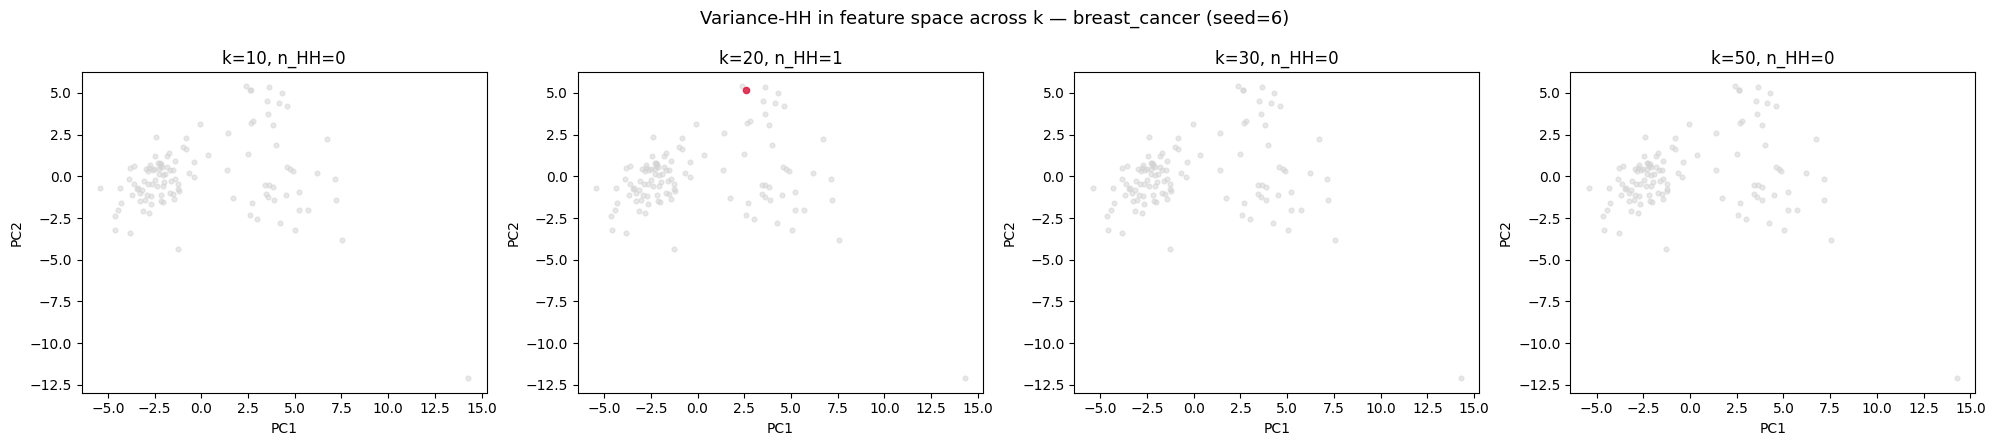

compas: representative seed = seed=2 (median Moran's I = 0.2155)


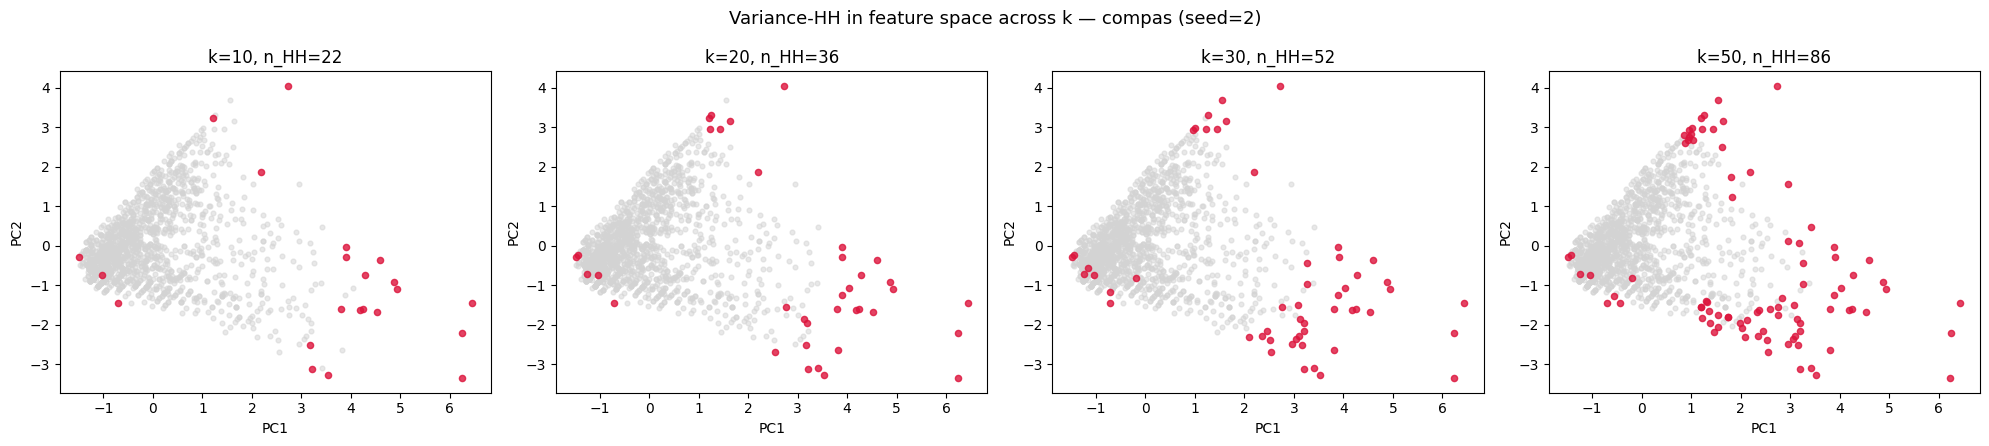

german: representative seed = seed=0 (median Moran's I = 0.1159)


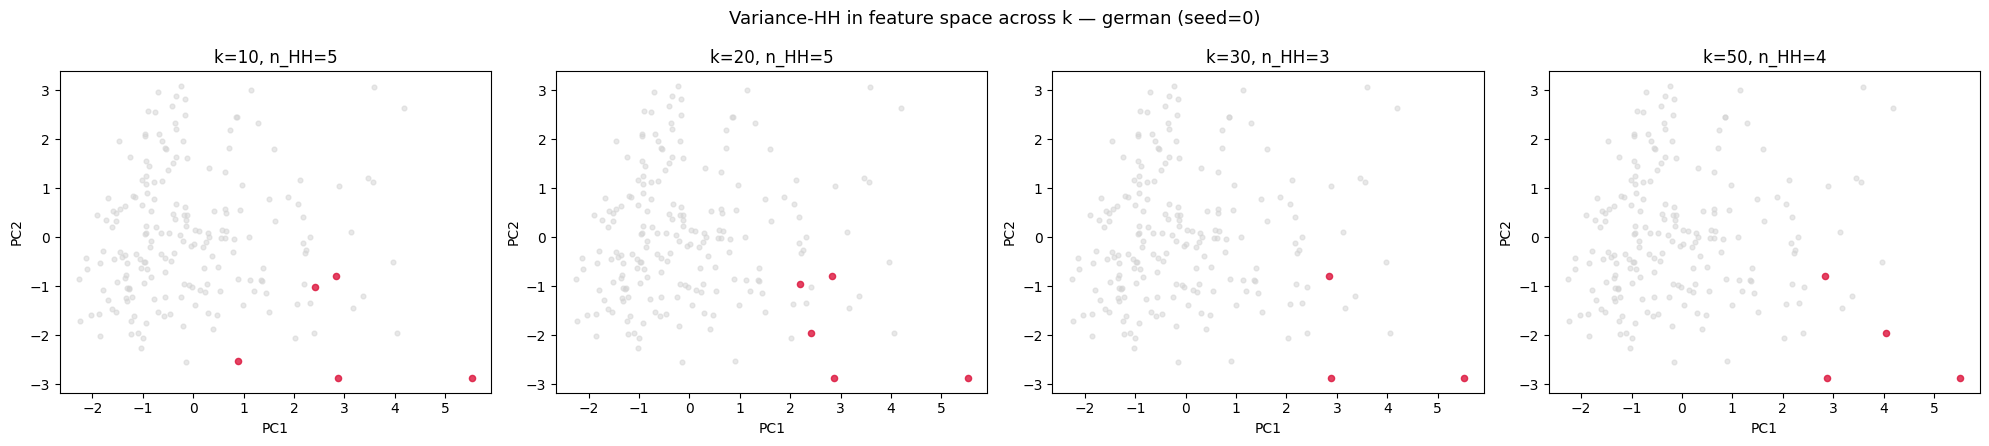

In [5]:
for ds_name in df_knn["dataset"].unique():
    ds_sub = df_knn[(df_knn["dataset"] == ds_name)]
    seeds = ds_sub["seed"].unique()

    moran_per_seed = ds_sub.groupby("seed")["moran_i"].mean()
    median_moran = moran_per_seed.median()
    rep_seed = moran_per_seed.index[np.argmin(np.abs(moran_per_seed.values - median_moran))]
    print(f"{ds_name}: representative seed = {rep_seed} (median Moran's I = {median_moran:.4f})")

    k_list = sorted(ds_sub["k_nn"].unique())
    n_k = len(k_list)
    fig, axes = plt.subplots(1, n_k, figsize=(5 * n_k, 4.5))
    if n_k == 1:
        axes = [axes]

    for ax, k_val in zip(axes, k_list):
        key = (ds_name, rep_seed, k_val)
        if key not in hh_data_by_knn:
            ax.set_title(f"k={k_val} (no data)")
            continue
        data = hh_data_by_knn[key]
        X_test = data["X_test"]
        hh = data["HH_mask"]
        n_features = X_test.shape[1]
        if n_features > 2:
            pca = PCA(n_components=2, random_state=42)
            coords = pca.fit_transform(X_test)
        else:
            coords = np.asarray(X_test)

        ax.scatter(coords[~hh, 0], coords[~hh, 1], c="lightgray", s=12, alpha=0.5)
        ax.scatter(coords[hh, 0], coords[hh, 1], c="crimson", s=20, alpha=0.8)
        ax.set_title(f"k={k_val}, n_HH={int(hh.sum())}")
        ax.set_xlabel("PC1" if n_features > 2 else "Feature 1")
        ax.set_ylabel("PC2" if n_features > 2 else "Feature 2")

    fig.suptitle(f"Variance-HH in feature space across k — {ds_name} ({rep_seed})", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"sensitivity_kNN_pca_hh_{ds_name}.pdf", bbox_inches="tight")
    plt.show()

## Interpret stability

If spatial statistics change little for k ≥ 20–30, the kNN graph choice is stable.